In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [67]:
df = pd.read_csv("data/player_data_COMPLETE.csv")

Filtramos para que nos salgan únicamente los jugadores de la posición que queremos

In [68]:
df_cb_todos = df[df["main_position"] == "CB"].copy()
df_cb = df_cb_todos[df_cb_todos["low_minutes_flag"] == False].copy()

Selección de métricas

In [69]:
features_cb = [
    "passes_avg",
    "progressive_pass_avg",
    "duels_won_avg",
    "interceptions_avg",
    "successful_defensive_actions_avg",
    "aerial_duels_won_avg"
]

X = df_cb[features_cb].fillna(0)

Escalado

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [71]:
df_scaled = pd.DataFrame(X_scaled, columns=features_cb)
print("\nDatos estandarizados:")
print(df_scaled.head())


Datos estandarizados:
   passes_avg  progressive_pass_avg  duels_won_avg  interceptions_avg  \
0   -1.158790             -0.344351       0.885186           0.480383   
1   -0.123713             -1.071964      -1.387634          -0.212643   
2   -0.018652              2.298595       0.483591           0.410076   
3   -1.279674             -1.318803       0.980275           0.481473   
4   -1.471231             -1.751426      -0.471079           0.209199   

   successful_defensive_actions_avg  aerial_duels_won_avg  
0                          1.120236              0.380158  
1                         -0.481402             -1.402087  
2                          0.933031              0.178718  
3                          0.703023              1.370540  
4                         -0.516069              1.383314  


PCA: Reducción de dimensionalidad

In [72]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.39102167 0.25952281]


In [73]:
n_components = 2
pca_df = pd.DataFrame(data=X_pca, columns=[f'PC{i}' for i in range(1, n_components+1)])
print("\nComponentes principales:")
print(pca_df.head())


Componentes principales:
        PC1       PC2
0  1.728505 -0.695358
1 -1.487056 -1.484522
2  0.956670  1.642752
3  1.953953 -1.152536
4  0.475880 -1.927724


C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the

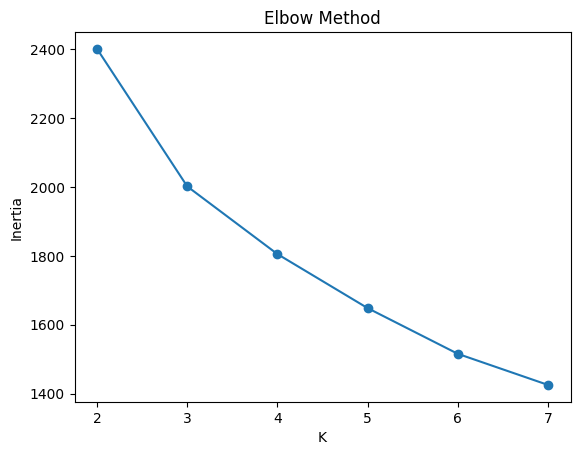

In [74]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [75]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_cb["cb_cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [76]:
cluster_profile = df_cb.groupby("cb_cluster")[features_cb].mean()
print(cluster_profile)

            passes_avg  progressive_pass_avg  duels_won_avg  \
cb_cluster                                                    
0            42.525288              6.963576       8.394935   
1            59.530066              9.011550       7.391689   
2            41.867953              6.539503       8.270524   
3            42.988698              6.305664       6.026608   

            interceptions_avg  successful_defensive_actions_avg  \
cb_cluster                                                        
0                    5.539710                         10.057838   
1                    4.083482                          7.695651   
2                    4.619605                          8.228188   
3                    3.979799                          7.197003   

            aerial_duels_won_avg  
cb_cluster                        
0                       2.088984  
1                       2.030058  
2                       3.063156  
3                       1.460211  


In [77]:
cols_show = ["id", "name", "market_value", "main_position", "minutes_on_field", "cb_cluster"]

df_cb_view = df_cb[cols_show].sort_values(
    ["cb_cluster", "market_value"],
    ascending=[True, False]
)

for c in sorted(df_cb["cb_cluster"].unique()):
    print(f"\n--- CLUSTER {c} ---")
    display(df_cb_view[df_cb_view["cb_cluster"] == c].head(10))


--- CLUSTER 0 ---


,id,name,market_value,main_position,minutes_on_field,cb_cluster
3021,396792,K. Danso,25000000.0,CB,2361,0
3566,465846,N. Collins,25000000.0,CB,3895,0
3798,500094,Dani Vivian,25000000.0,CB,3040,0
2440,263781,J. Giménez,22000000.0,CB,1675,0
3693,481220,I. Hien,20000000.0,CB,2659,0
3705,482559,M. Lacroix,20000000.0,CB,3819,0
3160,419697,Diogo Leite,15000000.0,CB,2465,0
3461,456479,J. Foyth,15000000.0,CB,2259,0
3598,470002,N. Casale,14000000.0,CB,877,0
1362,-102328,A. Al Dakhil,12000000.0,CB,601,0



--- CLUSTER 1 ---


,id,name,market_value,main_position,minutes_on_field,cb_cluster
1453,-92877,W. Saliba,80000000.0,CB,3224,1
2552,290253,Rúben Dias,80000000.0,CB,2797,1
3231,426558,A. Bastoni,70000000.0,CB,2593,1
3287,433485,Gabriel Magalhaes,70000000.0,CB,2670,1
3477,459276,R. Araújo,70000000.0,CB,1559,1
3289,433963,C. Romero,65000000.0,CB,1417,1
1117,-134252,L. Colwill,50000000.0,CB,2406,1
2138,180884,Marquinhos,50000000.0,CB,1438,1
3612,471671,L. Martínez,50000000.0,CB,949,1
861,-161508,Gonçalo Inácio,45000000.0,CB,2582,1



--- CLUSTER 2 ---


,id,name,market_value,main_position,minutes_on_field,cb_cluster
3572,466684,A. Tchouaméni,100000000.0,CB,2989,2
3039,399768,M. de Ligt,65000000.0,CB,2609,2
3217,425510,Éder Militão,60000000.0,CB,902,2
3541,463014,S. Botman,45000000.0,CB,1193,2
1219,-118836,J. Branthwaite,42000000.0,CB,2685,2
3659,477041,M. Kilman,32000000.0,CB,3832,2
2936,380617,G. Mancini,25000000.0,CB,3380,2
1735,-43127,Carlos Augusto,22000000.0,CB,2084,2
3145,417127,Igor Zubeldía,22000000.0,CB,2646,2
2150,182904,Aymeric Laporte,20000000.0,CB,806,2



--- CLUSTER 3 ---


,id,name,market_value,main_position,minutes_on_field,cb_cluster
1045,-140288,M. van de Ven,55000000.0,CB,1508,3
3201,423623,Pau Torres,45000000.0,CB,1939,3
2163,189445,J. Stones,38000000.0,CB,644,3
1239,-116593,O. Kossounou,35000000.0,CB,1419,3
2977,391059,D. Hancko,35000000.0,CB,1093,3
3267,431214,E. Konsa,35000000.0,CB,3447,3
3691,480539,J. Todibo,35000000.0,CB,2097,3
3551,463698,L. Geertruida,32000000.0,CB,1600,3
1100,-135524,Cristhian Mosquera,30000000.0,CB,2937,3
2171,192187,A. Rüdiger,25000000.0,CB,1520,3


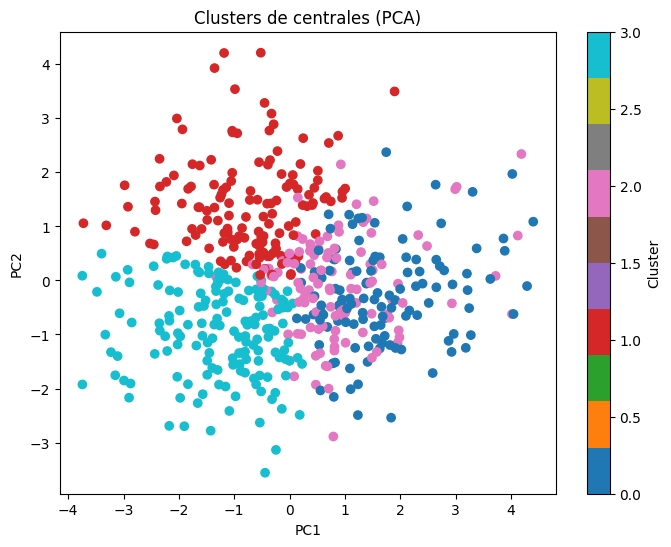

In [78]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_cb["cb_cluster"],
    cmap="tab10"
)

plt.title("Clusters de centrales (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")
plt.show()

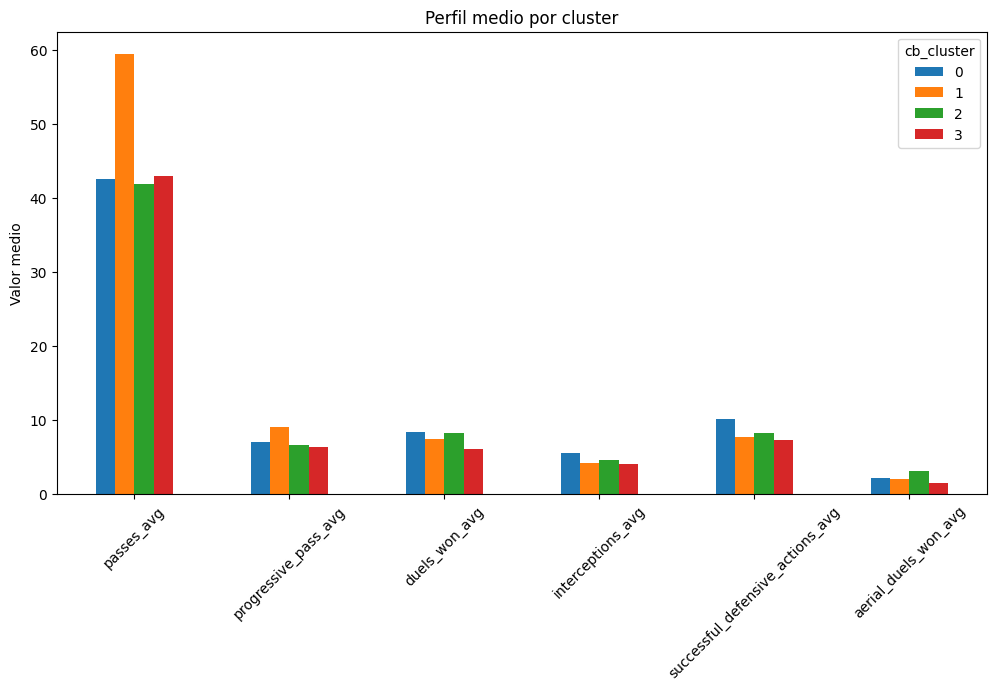

In [79]:
cluster_profile.T.plot(kind="bar", figsize=(12,6))
plt.title("Perfil medio por cluster")
plt.xticks(rotation=45)
plt.ylabel("Valor medio")
plt.show()

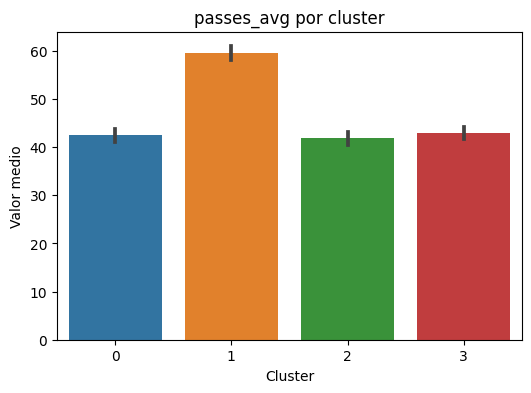

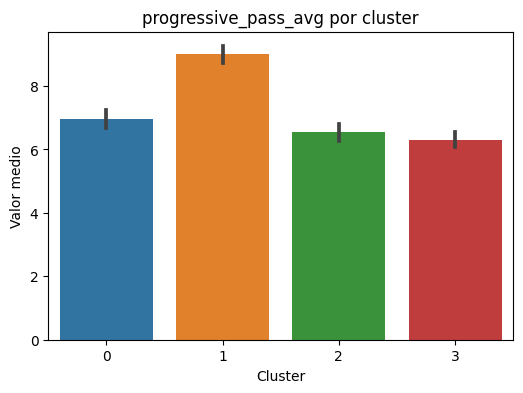

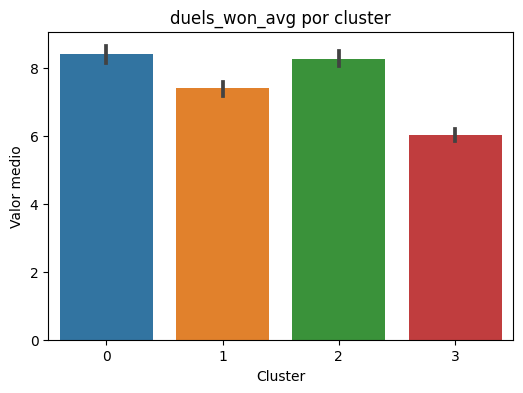

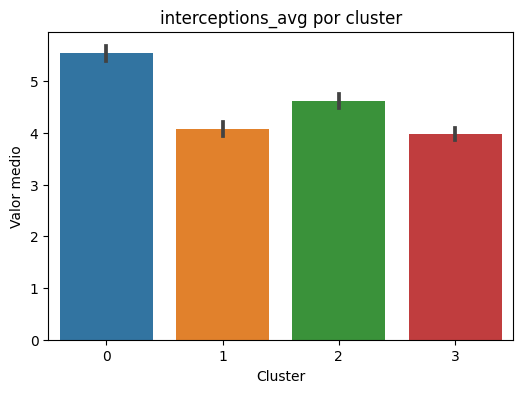

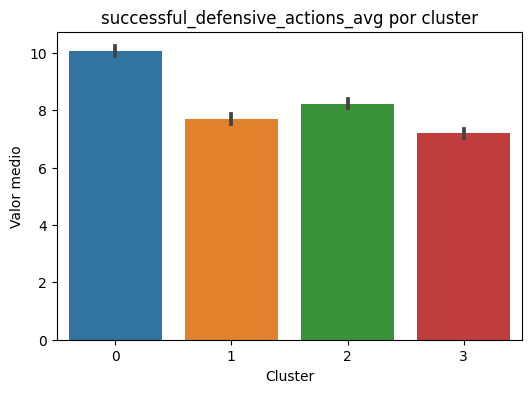

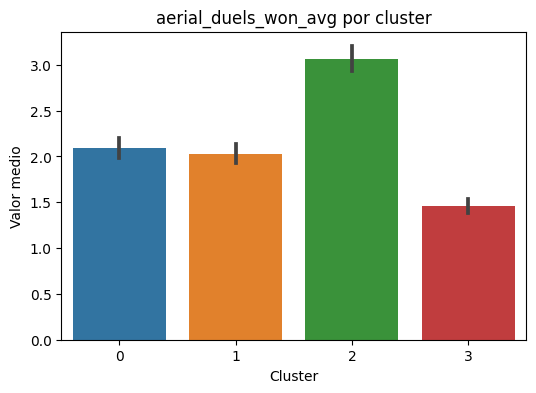

In [80]:
for col in features_cb:
    
    plt.figure(figsize=(6,4))
    
    sns.barplot(
        x="cb_cluster",
        y=col,
        data=df_cb
    )
    
    plt.title(f"{col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Valor medio")
    
    plt.show()

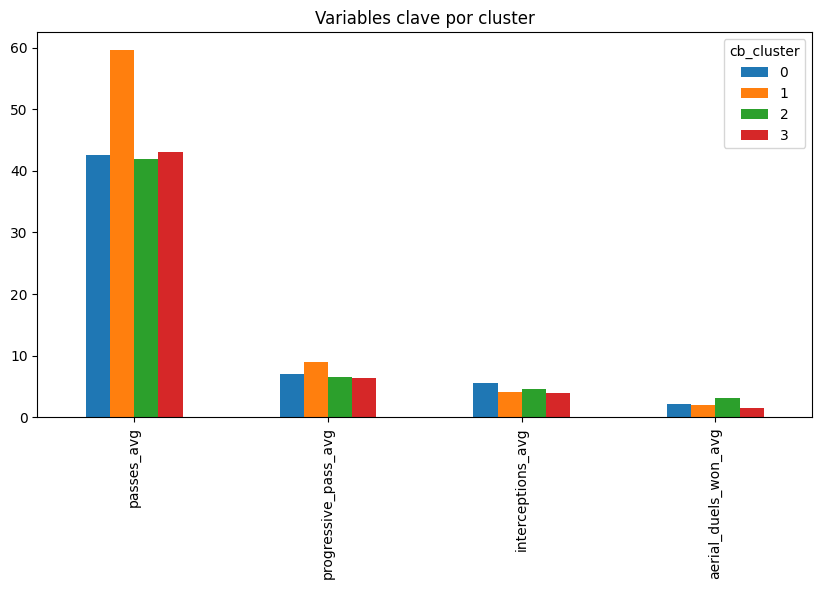

In [81]:
key_vars = [
    "passes_avg",
    "progressive_pass_avg",
    "interceptions_avg",
    "aerial_duels_won_avg"
]

df_cb.groupby("cb_cluster")[key_vars].mean().T.plot(kind="bar", figsize=(10,5))
plt.title("Variables clave por cluster")
plt.show()

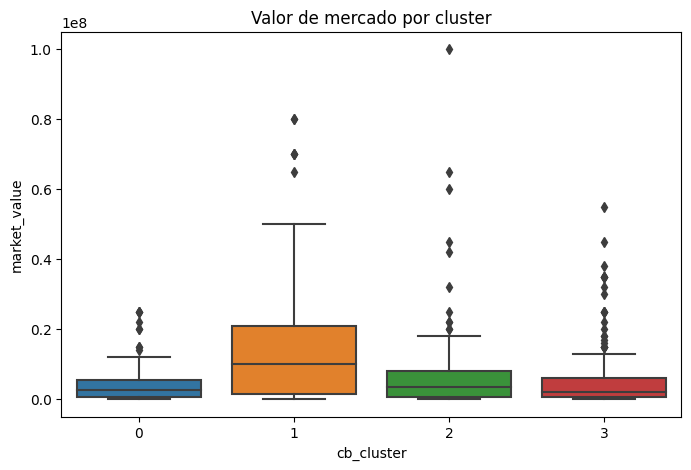

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cb_cluster", y="market_value", data=df_cb)
plt.title("Valor de mercado por cluster")
plt.show()

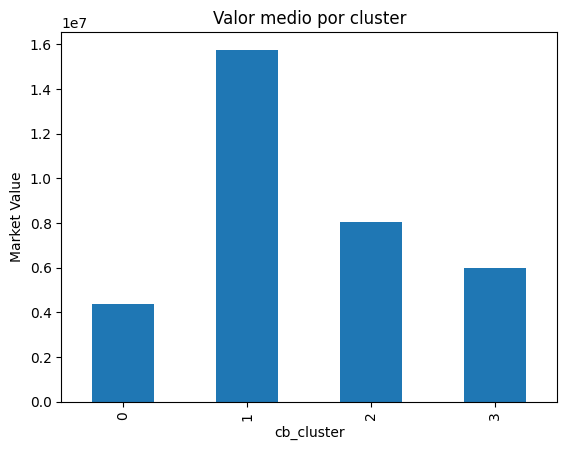

In [83]:
df_cb.groupby("cb_cluster")["market_value"].mean().plot(kind="bar")

plt.title("Valor medio por cluster")
plt.ylabel("Market Value")
plt.show()

In [84]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features_cb,
    index=["PC1", "PC2"]
)

display(loadings)

,passes_avg,progressive_pass_avg,duels_won_avg,interceptions_avg,successful_defensive_actions_avg,aerial_duels_won_avg
PC1,-0.225928,-0.039589,0.482173,0.499781,0.580086,0.358634
PC2,0.650955,0.661112,0.274800,-0.081084,-0.007566,0.238833


PC1 : duels + interceptions + defensive_actions + (un poco) aerial
PC2 : passes + progressive_pass + (un poco menos) aerial


CLUSTER 0 -> BALL STEALER CB

CLUSTER 1 -> BALL PLAYING CB

CLUSTER 2 -> AERIAL DOMINANT CB

CLUSTER 3 -> LOW-IMPACT CB


In [85]:
cluster_profile

,passes_avg,progressive_pass_avg,duels_won_avg,interceptions_avg,successful_defensive_actions_avg,aerial_duels_won_avg
cb_cluster,,,,,,
0,42.525288,6.963576,8.394935,5.539710,10.057838,2.088984
1,59.530066,9.011550,7.391689,4.083482,7.695651,2.030058
2,41.867953,6.539503,8.270524,4.619605,8.228188,3.063156
3,42.988698,6.305664,6.026608,3.979799,7.197003,1.460211


Guardarlo como csv clustering

In [86]:
df_cb[["id", "cb_cluster"]]

,id,cb_cluster
8,-680280,0
16,-660568,3
67,-524863,1
86,-471601,2
97,-460265,2
...,...,...
3901,517739,3
3908,519211,3
3917,521940,2
3920,522867,3


In [87]:
cb_labels = {
    0: "Ball-stealing CB",
    1: "Ball-playing CB",
    2: "Aerial dominant CB",
    3: "Low-impact CB"
}

fb_labels = {
    0: "Attacking full-back",
    1: "Creative full-back",
    2: "Low-impact full-back",
    3: "Defensive full-back"
}

mf_labels = {
    0: "Attacking midfielder",
    1: "Low-impact midfielder",
    2: "Deep-lying playmaker",
    3: "Ball-winning midfielder"
}

w_labels = {
    0: "Dribbler winger",
    1: "Low-impact winger",
    2: "Defensive winger",
    3: "Goal-scoring winger"
}

fw_labels = {
    0: "Target man",
    1: "Pressing forward",
    2: "Creative forward",
    3: "Poacher"
}

gk_labels = {
    0: "Low-performing GK",
    1: "Shot-stopper GK",
    2: "Ball-playing GK",
    3: "Low-impact GK"
}

In [88]:
def assign_role(row):

    if row["main_position"] == "CB" and pd.notna(row["cb_cluster"]):
        return cb_labels.get(row["cb_cluster"])

    elif row["main_position"] == "FB" and pd.notna(row["fb_cluster"]):
        return fb_labels.get(row["fb_cluster"])

    elif row["main_position"] == "MF" and pd.notna(row["mf_cluster"]):
        return mf_labels.get(row["mf_cluster"])

    elif row["main_position"] == "W" and pd.notna(row["w_cluster"]):
        return w_labels.get(row["w_cluster"])

    elif row["main_position"] == "FW" and pd.notna(row["fw_cluster"]):
        return fw_labels.get(row["fw_cluster"])

    elif row["main_position"] == "GK" and pd.notna(row["gk_cluster"]):
        return gk_labels.get(row["gk_cluster"])

    return None

In [89]:
df_cb["player_role"] = df_cb.apply(assign_role, axis=1)

In [91]:
df_cb

,id,age,market_value,total_matches,primary_position_percent,secondary_position_percent,third_position_percent,height,weight,goals,...,aerial_duels_won_avg,positions_clean,main_position,direct_free_kick_taker,corner_taker,penalty_taker,shot_efficiency,shot_efficiency_avg,cb_cluster,player_role
8,-680280,23.0,0.0,12.000000,43.000000,43.000000,0.0,0.0,0.0,0.0,...,2.415849,"['LCB3', 'LCB']",CB,False,False,False,-0.030000,-0.030000,0,Ball-stealing CB
16,-660568,17.0,0.0,12.000000,100.000000,0.000000,0.0,0.0,0.0,0.0,...,0.920000,['LCB'],CB,False,False,False,0.000000,0.000000,3,Low-impact CB
67,-524863,21.0,0.0,7.000000,100.000000,0.000000,0.0,191.0,79.0,0.0,...,2.246779,['LCB3'],CB,False,False,False,-0.070000,-0.070000,1,Ball-playing CB
86,-471601,20.0,0.0,12.573235,71.732345,16.170009,0.0,194.0,0.0,1.0,...,3.247083,"['RCB3', 'RCB']",CB,False,False,False,0.014756,0.014756,2,Aerial dominant CB
97,-460265,21.0,0.0,14.000000,55.000000,19.000000,18.0,186.0,85.0,0.0,...,3.257804,"['RCB', 'LCB', 'CB']",CB,False,False,False,-0.070000,-0.070000,2,Aerial dominant CB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3901,517739,23.0,25000000.0,12.000000,94.000000,0.000000,0.0,191.0,82.0,0.0,...,1.590000,['RCB'],CB,False,False,False,-0.040000,-0.040000,3,Low-impact CB
3908,519211,23.0,0.0,17.000000,47.000000,13.000000,11.0,187.0,74.0,0.0,...,1.091550,"['CB', 'LCB', 'DMF']",CB,False,False,False,-0.040000,-0.040000,3,Low-impact CB
3917,521940,25.0,1800000.0,12.000000,51.000000,38.000000,0.0,192.0,85.0,0.0,...,3.242400,"['LCB3', 'RCB3']",CB,False,False,False,-0.040000,-0.040000,2,Aerial dominant CB
3920,522867,25.0,22000000.0,22.000000,92.000000,0.000000,0.0,186.0,76.0,3.0,...,1.460646,['LCB'],CB,False,False,False,0.090000,0.090000,3,Low-impact CB


In [93]:
df_cb[["id", "name", "cb_cluster", "player_role"]].to_csv("clustering/data/cb_clusters.csv", index=False)